# Estudio Exploratorio de Datos – ICFES Saber 11

Este notebook carga el dataset limpio desde Kaggle (`datos-icfes-11-clean`) y genera
visualizaciones exploratorias enfocadas en equidad: brechas por área (urbano/rural),
estrato, género, tipo de colegio y departamento.

**Prerequisito:** haber ejecutado `01_presentacion_datos.ipynb` para generar y subir el dataset limpio.

## 1. Carga del dataset limpio desde Kaggle

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd

df = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "jacoboayala/datos-icfes-11",
    "v2_datos_limpios.csv",
    pandas_kwargs={"sep": ";", "low_memory": False}
)

print(f"Filas: {len(df):,}  |  Columnas: {df.shape[1]}")
df.head(3)

Resuming download from 644874240 bytes (314395433 bytes left)...
Resuming download from https://www.kaggle.com/api/v1/datasets/download/jacoboayala/datos-icfes-11?dataset_version_number=2&file_name=v2_datos_limpios.csv (644874240/959269673) bytes left.


100%|██████████| 915M/915M [00:04<00:00, 65.8MB/s]


Filas: 4,821,037  |  Columnas: 28


,cole_area_ubicacion,cole_bilingue,cole_calendario,cole_caracter,cole_depto_ubicacion,cole_genero,cole_jornada,cole_mcpio_ubicacion,cole_naturaleza,cole_sede_principal,...,fami_estratovivienda,fami_personashogar,fami_tieneautomovil,fami_tienecomputador,fami_tieneinternet,fami_tienelavadora,fami_tieneserviciotv,punt_global,anio,semestre
0,Rural,N,A,TÉCNICO/ACADÉMICO,VALLE,MIXTO,MAÑANA,BUENAVENTURA,Oficial,S,...,Estrato 1,Tres,No,No,No,No,No,274,2014,2
1,Urbano,N,A,TÉCNICO/ACADÉMICO,CHOCO,MIXTO,MAÑANA,MEDIO SAN JUAN,Oficial,S,...,Estrato 1,Cinco,No,No,No,Si,No,222,2014,2
2,Urbano,N,A,TÉCNICO/ACADÉMICO,META,MIXTO,MAÑANA,VILLAVICENCIO,Oficial,S,...,Estrato 2,Cuatro,Si,Si,Si,Si,Si,358,2014,2


## 2. Configuración visual

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.1)
PALETTE_AREA  = {"Urbano": "#2196F3", "Rural": "#4CAF50"}
PALETTE_NAT   = {"Oficial": "#FF5722", "No Oficial": "#9C27B0"}
PALETTE_GEN   = {"M": "#1976D2", "F": "#E91E63"}
FIG_W, FIG_H  = 14, 5

## 3. Distribución del puntaje global

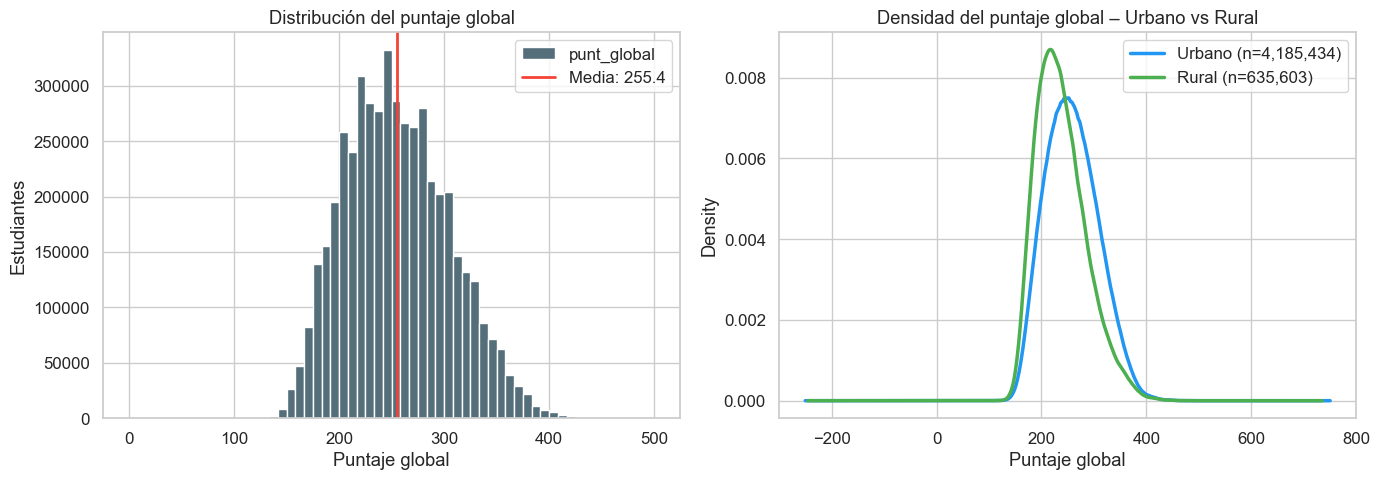

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Histograma general
ax = axes[0]
df["punt_global"].dropna().plot.hist(bins=60, color="#546E7A", edgecolor="white", ax=ax)
ax.axvline(df["punt_global"].mean(), color="#F44336", lw=2, label=f'Media: {df["punt_global"].mean():.1f}')
ax.set_title("Distribución del puntaje global")
ax.set_xlabel("Puntaje global")
ax.set_ylabel("Estudiantes")
ax.legend()

# KDE por área
ax2 = axes[1]
for area, color in PALETTE_AREA.items():
    subset = df[df["cole_area_ubicacion"] == area]["punt_global"].dropna()
    if len(subset) > 0:
        subset.plot.kde(ax=ax2, color=color, lw=2.5, label=f"{area} (n={len(subset):,})")
ax2.set_title("Densidad del puntaje global – Urbano vs Rural")
ax2.set_xlabel("Puntaje global")
ax2.legend()

plt.tight_layout()
plt.show()

## 4. Evolución temporal del puntaje global

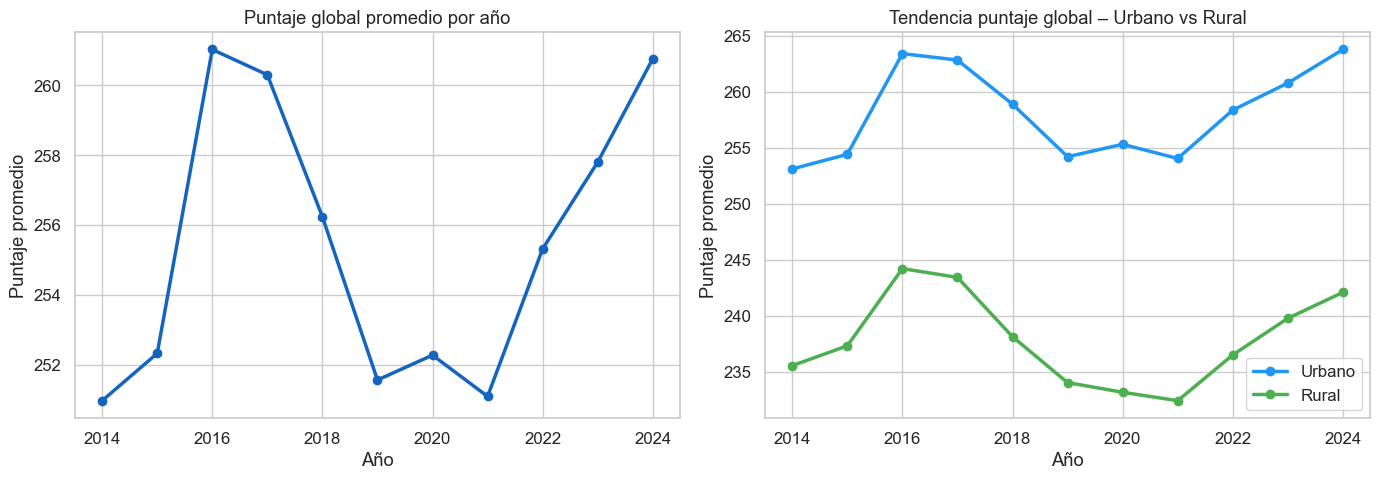

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

# Promedio por año
trend = df.groupby("anio")["punt_global"].mean().reset_index()
ax = axes[0]
ax.plot(trend["anio"], trend["punt_global"], marker="o", color="#1565C0", lw=2.5)
ax.set_title("Puntaje global promedio por año")
ax.set_xlabel("Año")
ax.set_ylabel("Puntaje promedio")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# Promedio por año y área
trend_area = df.groupby(["anio", "cole_area_ubicacion"])["punt_global"].mean().reset_index()
ax2 = axes[1]
for area, color in PALETTE_AREA.items():
    sub = trend_area[trend_area["cole_area_ubicacion"] == area]
    ax2.plot(sub["anio"], sub["punt_global"], marker="o", color=color, lw=2.5, label=area)
ax2.set_title("Tendencia puntaje global – Urbano vs Rural")
ax2.set_xlabel("Año")
ax2.set_ylabel("Puntaje promedio")
ax2.legend()
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 5. Brecha urbano-rural por año

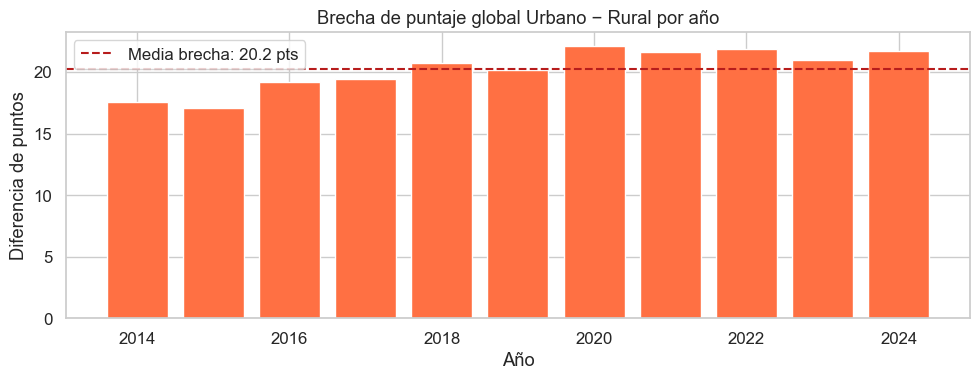

In [6]:
pivot = (
    df[df["cole_area_ubicacion"].isin(["Urbano", "Rural"])]
    .groupby(["anio", "cole_area_ubicacion"])["punt_global"]
    .mean()
    .unstack()
)
pivot["brecha"] = pivot["Urbano"] - pivot["Rural"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(pivot.index, pivot["brecha"], color="#FF7043", edgecolor="white")
ax.axhline(pivot["brecha"].mean(), color="#B71C1C", ls="--", lw=1.5,
           label=f'Media brecha: {pivot["brecha"].mean():.1f} pts')
ax.set_title("Brecha de puntaje global Urbano − Rural por año")
ax.set_xlabel("Año")
ax.set_ylabel("Diferencia de puntos")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 6. Puntaje global por estrato socioeconómico

/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_3674/523073638.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


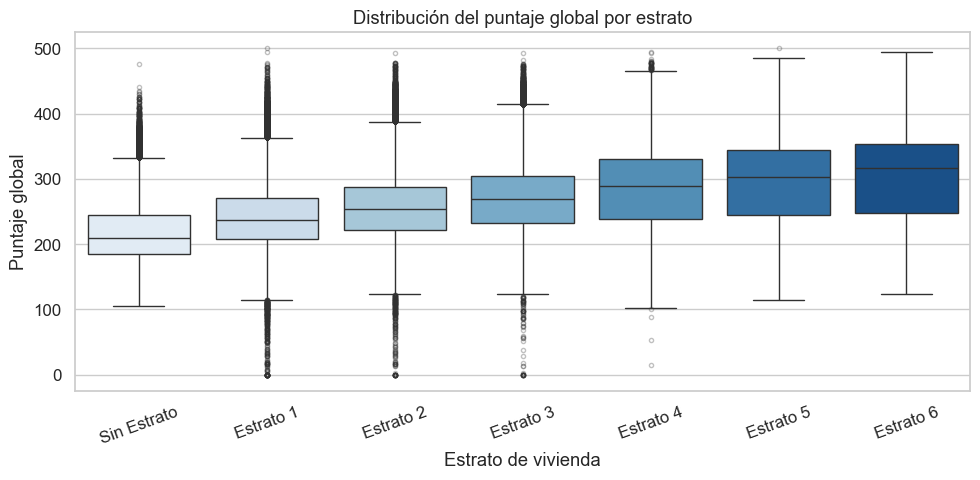

In [7]:
orden_estrato = ["Sin Estrato", "Estrato 1", "Estrato 2", "Estrato 3",
                 "Estrato 4", "Estrato 5", "Estrato 6"]

df["fami_estratovivienda"] = df["fami_estratovivienda"].str.strip().str.title()
estrato_validos = df[df["fami_estratovivienda"].isin(orden_estrato)]

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=estrato_validos, x="fami_estratovivienda", y="punt_global",
    order=orden_estrato, palette="Blues", flierprops=dict(marker=".", alpha=0.3), ax=ax
)
ax.set_title("Distribución del puntaje global por estrato")
ax.set_xlabel("Estrato de vivienda")
ax.set_ylabel("Puntaje global")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

## 7. Puntaje global por tipo de colegio (oficial vs no oficial)

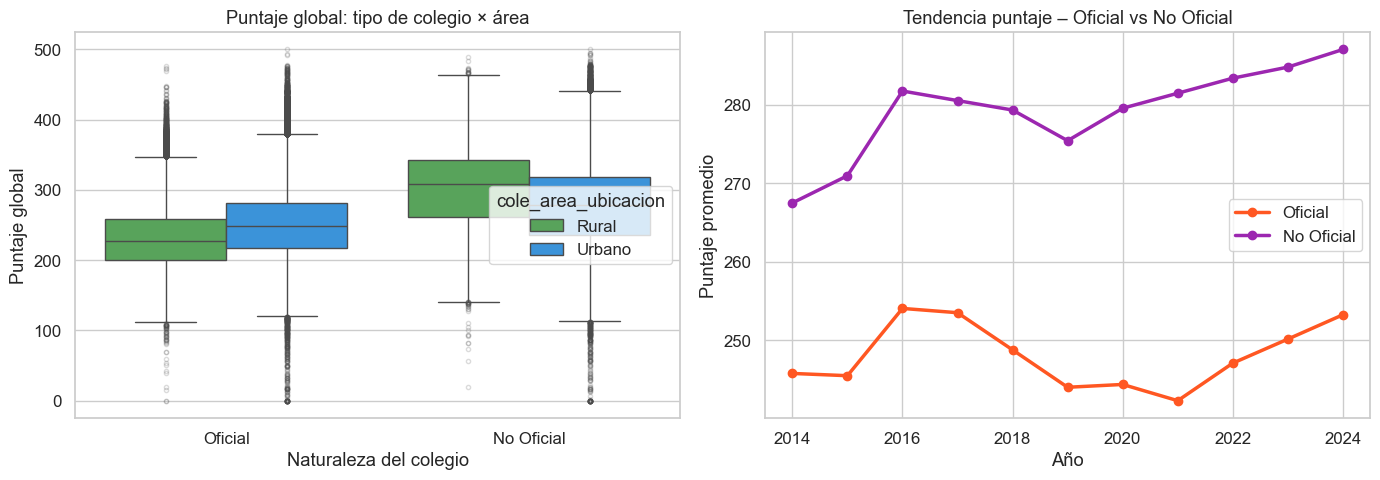

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(FIG_W, FIG_H))

ax = axes[0]
orden_nat = ["Oficial", "No Oficial"]
sns.boxplot(
    data=df[df["cole_naturaleza"].isin(orden_nat)],
    x="cole_naturaleza", y="punt_global", hue="cole_area_ubicacion",
    order=orden_nat, palette=PALETTE_AREA,
    flierprops=dict(marker=".", alpha=0.2), ax=ax
)
ax.set_title("Puntaje global: tipo de colegio × área")
ax.set_xlabel("Naturaleza del colegio")
ax.set_ylabel("Puntaje global")

trend_nat = df.groupby(["anio", "cole_naturaleza"])["punt_global"].mean().reset_index()
ax2 = axes[1]
for nat, color in PALETTE_NAT.items():
    sub = trend_nat[trend_nat["cole_naturaleza"] == nat]
    ax2.plot(sub["anio"], sub["punt_global"], marker="o", color=color, lw=2.5, label=nat)
ax2.set_title("Tendencia puntaje – Oficial vs No Oficial")
ax2.set_xlabel("Año")
ax2.set_ylabel("Puntaje promedio")
ax2.legend()
ax2.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

## 8. Brecha de género

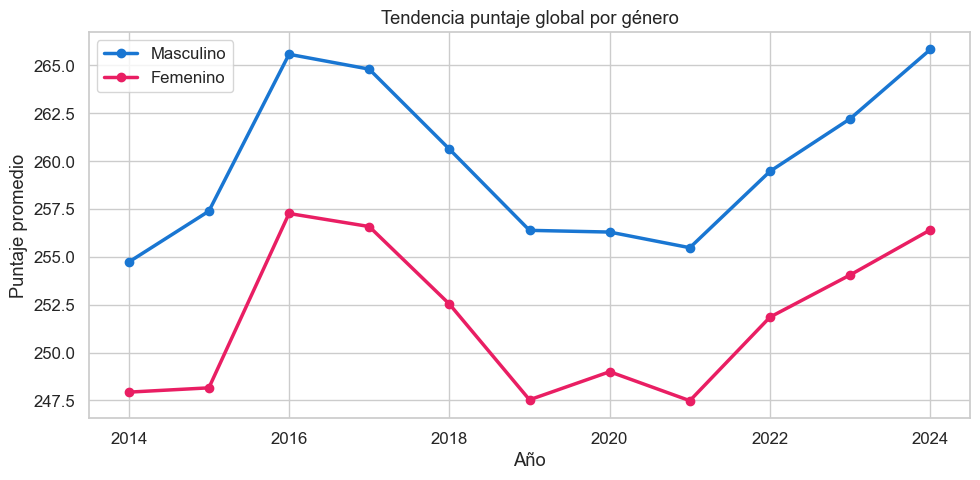

In [9]:
genero_valido = df[df["estu_genero"].isin(["M", "F"])]

trend_gen = genero_valido.groupby(["anio", "estu_genero"])["punt_global"].mean().reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
for gen, color in PALETTE_GEN.items():
    sub = trend_gen[trend_gen["estu_genero"] == gen]
    lbl = "Masculino" if gen == "M" else "Femenino"
    ax.plot(sub["anio"], sub["punt_global"], marker="o", color=color, lw=2.5, label=lbl)
ax.set_title("Tendencia puntaje global por género")
ax.set_xlabel("Año")
ax.set_ylabel("Puntaje promedio")
ax.legend()
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
plt.tight_layout()
plt.show()

## 9. Acceso a tecnología y puntaje

/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_3674/3980956520.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=col, y="punt_global", order=orden,
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_3674/3980956520.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=col, y="punt_global", order=orden,
/var/folders/ft/qv81dsnx27v1c47hmvjljxv40000gn/T/ipykernel_3674/3980956520.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub, x=col, y="punt_global", order=orden,
/var/folders/ft/qv81ds

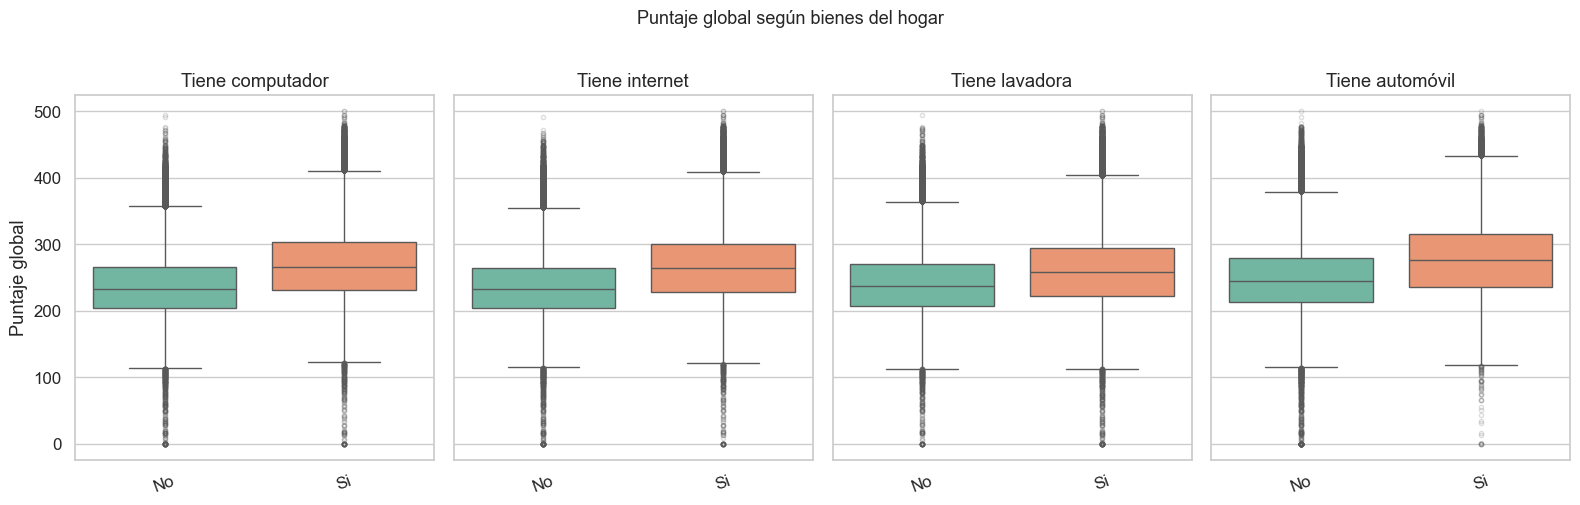

In [10]:
tech_cols = {
    "fami_tienecomputador": "Tiene computador",
    "fami_tieneinternet":   "Tiene internet",
    "fami_tienelavadora":   "Tiene lavadora",
    "fami_tieneautomovil":  "Tiene automóvil",
}

fig, axes = plt.subplots(1, len(tech_cols), figsize=(16, 5), sharey=True)

for ax, (col, titulo) in zip(axes, tech_cols.items()):
    sub = df[[col, "punt_global"]].dropna()
    sub[col] = sub[col].str.strip().str.title()
    orden = sorted(sub[col].unique())
    sns.boxplot(data=sub, x=col, y="punt_global", order=orden,
                palette="Set2", flierprops=dict(marker=".", alpha=0.2), ax=ax)
    ax.set_title(titulo)
    ax.set_xlabel("")
    if ax == axes[0]:
        ax.set_ylabel("Puntaje global")
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Puntaje global según bienes del hogar", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 10. Puntaje global por departamento

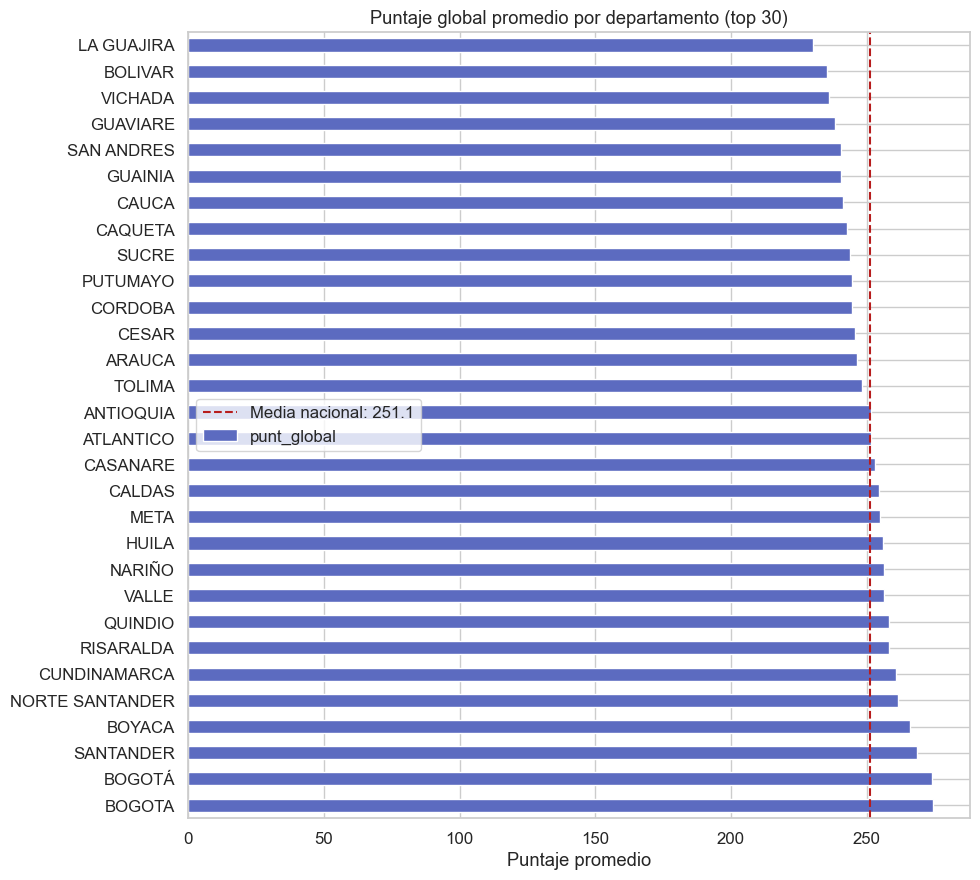

In [11]:
depto_media = (
    df.groupby("cole_depto_ubicacion")["punt_global"]
    .mean()
    .sort_values(ascending=False)
    .head(30)
)

fig, ax = plt.subplots(figsize=(10, 9))
depto_media.plot.barh(ax=ax, color="#5C6BC0", edgecolor="white")
ax.axvline(depto_media.mean(), color="#B71C1C", ls="--", lw=1.5,
           label=f"Media nacional: {depto_media.mean():.1f}")
ax.set_title("Puntaje global promedio por departamento (top 30)")
ax.set_xlabel("Puntaje promedio")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Educación de padres y puntaje global

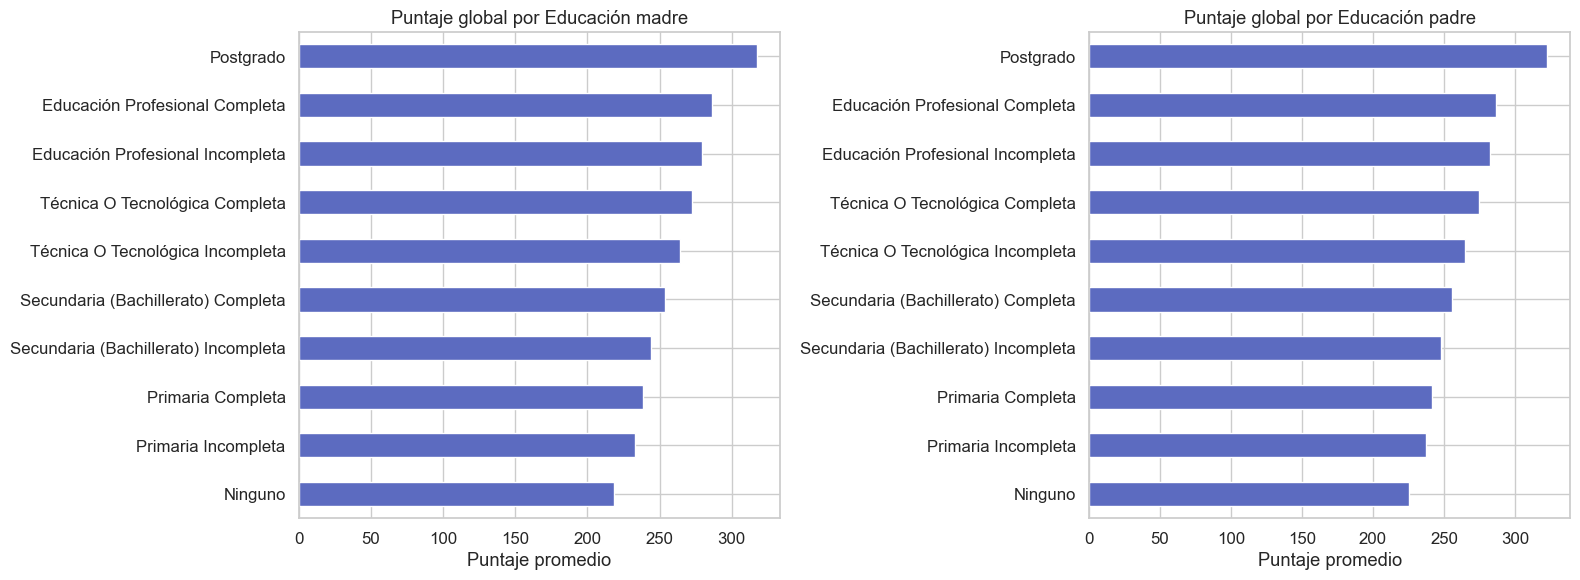

In [12]:
orden_edu = [
    "Ninguno",
    "Primaria Incompleta", "Primaria Completa",
    "Secundaria (Bachillerato) Incompleta", "Secundaria (Bachillerato) Completa",
    "Técnica O Tecnológica Incompleta", "Técnica O Tecnológica Completa",
    "Educación Profesional Incompleta", "Educación Profesional Completa",
    "Postgrado",
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, titulo in zip(
    axes,
    ["fami_educacionmadre", "fami_educacionpadre"],
    ["Educación madre", "Educación padre"]
):
    sub = df[[col, "punt_global"]].dropna()
    sub[col] = sub[col].str.strip().str.title()
    presentes = [o for o in orden_edu if o in sub[col].unique()]
    medias_edu = sub.groupby(col)["punt_global"].mean().reindex(presentes)
    medias_edu.plot.barh(ax=ax, color="#5C6BC0", edgecolor="white")
    ax.set_title(f"Puntaje global por {titulo}")
    ax.set_xlabel("Puntaje promedio")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 12. Resumen estadístico de brechas

In [13]:
resumen = {}

# Brecha urbano-rural
for area in ["Urbano", "Rural"]:
    resumen[f"Prom. {area}"] = df[df["cole_area_ubicacion"] == area]["punt_global"].mean()
resumen["Brecha Urbano-Rural"] = resumen["Prom. Urbano"] - resumen["Prom. Rural"]

# Brecha oficial-no oficial
for nat in ["Oficial", "No Oficial"]:
    resumen[f"Prom. {nat}"] = df[df["cole_naturaleza"] == nat]["punt_global"].mean()
resumen["Brecha Oficial/No Oficial"] = resumen["Prom. No Oficial"] - resumen["Prom. Oficial"]

# Brecha de género
for gen, label in [("M", "Hombres"), ("F", "Mujeres")]:
    resumen[f"Prom. {label}"] = df[df["estu_genero"] == gen]["punt_global"].mean()
resumen["Brecha Género (M-F)"] = resumen["Prom. Hombres"] - resumen["Prom. Mujeres"]

# Brecha estrato extremo
prom_e1 = df[df["fami_estratovivienda"] == "Estrato 1"]["punt_global"].mean()
prom_e6 = df[df["fami_estratovivienda"] == "Estrato 6"]["punt_global"].mean()
resumen["Prom. Estrato 1"] = prom_e1
resumen["Prom. Estrato 6"] = prom_e6
resumen["Brecha Estrato 6-1"] = prom_e6 - prom_e1

resumen_df = pd.Series(resumen).rename("Valor").to_frame()
resumen_df["Valor"] = resumen_df["Valor"].round(2)
resumen_df.style.background_gradient(cmap="RdYlGn", subset="Valor")

,Valor
Prom. Urbano,258.040000
Prom. Rural,237.910000
Brecha Urbano-Rural,20.130000
Prom. Oficial,248.090000
Prom. No Oficial,278.700000
Brecha Oficial/No Oficial,30.610000
Prom. Hombres,259.870000
Prom. Mujeres,251.660000
Brecha Género (M-F),8.210000
Prom. Estrato 1,240.870000
